2025-06-23 12:28:31,111 [INFO] - Starting model evaluation and visualization...
2025-06-23 12:28:31,148 [INFO] - ✓ Loaded XGBoost model
2025-06-23 12:28:31,149 [INFO] - ✓ Loaded XGBoost results
2025-06-23 12:28:31,150 [INFO] - ✓ Loaded Logistic Regression model
2025-06-23 12:28:31,151 [INFO] - ✓ Loaded Logistic Regression results
2025-06-23 12:28:31,930 [INFO] - Initial data shapes: X_test(5986, 478), y_test(5985,)
2025-06-23 12:28:31,943 [INFO] - ✓ Loaded aligned test data: X_test(5985, 478), y_test(5985,)
2025-06-23 12:28:31,946 [INFO] - Test set class distribution: {0: 5350, 1: 635}
2025-06-23 12:28:32,195 [INFO] - ✓ Generated predictions for XGBoost (AUROC: 0.8878, AUPRC: 0.5841)
2025-06-23 12:28:32,218 [INFO] - ✓ Generated predictions for Logistic Regression (AUROC: 0.8649, AUPRC: 0.5143)
2025-06-23 12:28:32,219 [INFO] - Creating visualizations...
2025-06-23 12:28:33,095 [INFO] - ✓ ROC curves saved to model_evaluation_outputs/roc_curves.png


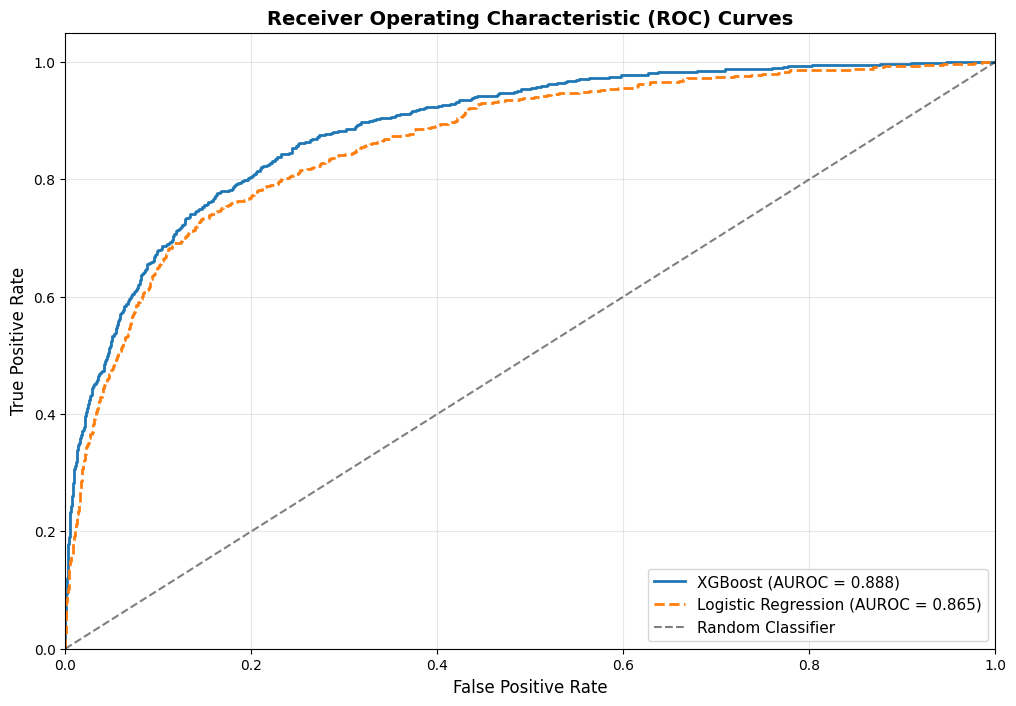

In [ ]:
# model_evaluation_and_visualization.py

import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix
)
import shap
import logging
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURATION
# =============================================================================

# Directories
PHASE_1_DIR = 'phase_1_outputs'
EVALUATION_DIR = 'model_evaluation_outputs'
os.makedirs(EVALUATION_DIR, exist_ok=True)

# Model files to compare
MODEL_FILES = {
    'XGBoost': {
        'model_path': os.path.join(PHASE_1_DIR, 'model_1_xgboost_baseline.pkl'),
        'results_path': os.path.join(PHASE_1_DIR, 'results_xgboost_baseline.pkl'),
        'color': '#1f77b4',
        'linestyle': '-'
    },
    'Logistic Regression': {
        'model_path': os.path.join(PHASE_1_DIR, 'model_1_logistic_baseline.pkl'),
        'results_path': os.path.join(PHASE_1_DIR, 'results_model_1_logistic.pkl'),
        'color': '#ff7f0e',
        'linestyle': '--'
    }
}

# Test data files
TEST_DATA_FILES = {
    'X_test': os.path.join(PHASE_1_DIR, 'X_test_engineered.csv'),
    'y_test': os.path.join(PHASE_1_DIR, 'y_test.csv')
}

# Plotting configuration
plt.style.use('default')
sns.set_palette("husl")
FIGURE_SIZE = (12, 8)
DPI = 300

# =============================================================================
# LOGGING SETUP
# =============================================================================

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] - %(message)s',
    handlers=[
        logging.FileHandler(os.path.join(EVALUATION_DIR, 'evaluation_log.txt'), mode='w'),
        logging.StreamHandler()
    ]
)

# =============================================================================
# DATA LOADING FUNCTIONS
# =============================================================================

def load_models_and_results():
    """Load all saved models and their results."""
    models = {}
    results = {}
    
    for model_name, paths in MODEL_FILES.items():
        try:
            # Load model
            if os.path.exists(paths['model_path']):
                with open(paths['model_path'], 'rb') as f:
                    models[model_name] = pickle.load(f)
                logging.info(f"✓ Loaded {model_name} model")
            else:
                logging.warning(f"Model file not found: {paths['model_path']}")
                continue
                
            # Load results
            if os.path.exists(paths['results_path']):
                with open(paths['results_path'], 'rb') as f:
                    results[model_name] = pickle.load(f)
                logging.info(f"✓ Loaded {model_name} results")
            else:
                logging.warning(f"Results file not found: {paths['results_path']}")
                
        except Exception as e:
            logging.error(f"Failed to load {model_name}: {e}")
            
    return models, results

def load_test_data():
    """Load the test dataset."""
    try:
        X_test = pd.read_csv(TEST_DATA_FILES['X_test'], index_col=0)
        y_test = pd.read_csv(TEST_DATA_FILES['y_test'], index_col=0).squeeze()
        
        logging.info(f"Initial data shapes: X_test{X_test.shape}, y_test{y_test.shape}")
        
        # Align the datasets by index to handle any mismatches
        common_index = X_test.index.intersection(y_test.index)
        X_test = X_test.loc[common_index]
        y_test = y_test.loc[common_index]
        
        logging.info(f"✓ Loaded aligned test data: X_test{X_test.shape}, y_test{y_test.shape}")
        logging.info(f"Test set class distribution: {dict(y_test.value_counts())}")
        
        # Verify alignment
        if X_test.shape[0] != y_test.shape[0]:
            raise ValueError(f"Shape mismatch after alignment: X_test{X_test.shape}, y_test{y_test.shape}")
        
        return X_test, y_test
    except Exception as e:
        logging.error(f"Failed to load test data: {e}")
        return None, None

def generate_predictions(models, X_test, y_test):
    """Generate predictions for all models."""
    predictions = {}
    
    for model_name, model in models.items():
        try:
            # Get predicted probabilities
            if hasattr(model, 'predict_proba'):
                y_pred_proba = model.predict_proba(X_test)[:, 1]
            else:
                # Fallback for models without predict_proba
                y_pred_proba = model.decision_function(X_test)
                # Normalize to [0,1] range
                y_pred_proba = (y_pred_proba - y_pred_proba.min()) / (y_pred_proba.max() - y_pred_proba.min())
            
            # Get binary predictions
            y_pred = model.predict(X_test)
            
            # Calculate metrics
            auroc = roc_auc_score(y_test, y_pred_proba)
            auprc = average_precision_score(y_test, y_pred_proba)
            
            predictions[model_name] = {
                'y_pred_proba': y_pred_proba,
                'y_pred': y_pred,
                'auroc': auroc,
                'auprc': auprc,
                'classification_report': classification_report(y_test, y_pred, output_dict=True),
                'confusion_matrix': confusion_matrix(y_test, y_pred)
            }
            
            logging.info(f"✓ Generated predictions for {model_name} (AUROC: {auroc:.4f}, AUPRC: {auprc:.4f})")
            
        except Exception as e:
            logging.error(f"Failed to generate predictions for {model_name}: {e}")
    
    return predictions

# =============================================================================
# FEATURE NAME UTILITIES
# =============================================================================

def create_feature_name_mapping(feature_names):
    """Create a mapping from long feature names to shorter, more readable versions."""
    mapping = {}
    
    # Common medical term abbreviations and simplifications
    abbreviations = {
        'alanine aminotransferase': 'ALT',
        'asparate aminotransferase': 'AST',
        'alkaline phosphate': 'ALP',
        'blood urea nitrogen': 'BUN',
        'glascow coma scale': 'GCS',
        'respiratory rate': 'RR',
        'heart rate': 'HR',
        'blood pressure': 'BP',
        'systolic blood pressure': 'SBP',
        'diastolic blood pressure': 'DBP',
        'mean blood pressure': 'MAP',
        'oxygen saturation': 'SpO2',
        'partial pressure': 'P',
        'temperature': 'Temp',
        'cardiac output': 'CO',
        'central venous pressure': 'CVP',
        'pulmonary artery pressure': 'PAP',
        'inspired oxygen': 'FiO2',
        'positive end expiratory pressure': 'PEEP',
        'tidal volume': 'TV',
        'glascow coma scale total': 'GCS Total',
        'glascow coma scale motor response': 'GCS Motor',
        'glascow coma scale verbal response': 'GCS Verbal',
        'glascow coma scale eye opening': 'GCS Eyes',
        '_mean': ' (avg)',
        '_std': ' (var)',
        '_slope_6h': ' (6h trend)',
        '_slope_24h': ' (24h trend)',
        '_encoded': ''
    }
    
    for name in feature_names:
        short_name = name.lower()
        
        # Apply abbreviations
        for long_term, short_term in abbreviations.items():
            short_name = short_name.replace(long_term, short_term)
        
        # Additional cleanup
        short_name = short_name.replace('  ', ' ').strip()
        
        # Capitalize first letter and limit length
        if len(short_name) > 25:
            # Try to truncate sensibly
            parts = short_name.split()
            if len(parts) > 1:
                short_name = ' '.join(parts[:2]) + '...'
            else:
                short_name = short_name[:22] + '...'
        
        short_name = short_name.capitalize()
        mapping[name] = short_name
    
    return mapping

def get_shap_feature_explanations():
    """Return explanations for common SHAP features in medical prediction models."""
    return {
        'explanation': """
        SHAP (SHapley Additive exPlanations) Feature Analysis
        
        These plots show how different clinical features contribute to mortality predictions:
        
        📊 In Summary Plots:
        • X-axis: SHAP value (impact on prediction) - Right=increases risk, Left=decreases risk
        • Colors: Feature values - 🔴 RED=high values, 🔵 BLUE=low values
        • Each dot represents how a feature value affects one patient's prediction
        
        Key Feature Categories:
        
        📊 Vital Signs: Heart rate, blood pressure, temperature, oxygen saturation
           - Normal ranges are typically protective
           - Extreme values (very high/low) increase risk
        
        🧪 Laboratory Values: Blood chemistry, organ function markers
           - ALT/AST: Liver function (high values indicate liver damage)
           - BUN/Creatinine: Kidney function (high values indicate kidney problems)
           - Lactate: Tissue oxygenation (high values indicate organ dysfunction)
        
        🫀 Cardiovascular: Cardiac output, blood pressures
           - Low cardiac output indicates heart failure
           - Extreme blood pressures (very high/low) increase risk
        
        🫁 Respiratory: Oxygen levels, breathing support
           - Low oxygen saturation indicates respiratory failure
           - High PEEP/FiO2 indicates severe lung problems
        
        🧠 Neurological: Glasgow Coma Scale (consciousness level)
           - Lower GCS scores indicate worse brain function
        
        📈 Trends: Changes in values over time (6h/24h slopes)
           - Worsening trends (negative slopes for good values) increase risk
           - Improving trends (positive slopes for good values) are protective
        """,
        'waterfall_explanation': """
        Waterfall Plot Interpretation:
        
        • The plot shows how each feature pushes the prediction above or below the baseline
        • Baseline (E[f(X)]): Average prediction across all patients
        • Red bars: Features increasing mortality risk for this patient
        • Blue bars: Features decreasing mortality risk for this patient
        • Final prediction: Sum of baseline + all feature contributions
        """
    }

# =============================================================================
# VISUALIZATION FUNCTIONS
# =============================================================================

def plot_roc_curves(predictions, y_test, save_path=None):
    """Plot ROC curves for all models."""
    plt.figure(figsize=FIGURE_SIZE)
    
    for model_name, pred_data in predictions.items():
        fpr, tpr, _ = roc_curve(y_test, pred_data['y_pred_proba'])
        auroc = pred_data['auroc']
        
        plt.plot(fpr, tpr, 
                label=f"{model_name} (AUROC = {auroc:.3f})",
                color=MODEL_FILES[model_name]['color'],
                linestyle=MODEL_FILES[model_name]['linestyle'],
                linewidth=2)
    
    # Plot diagonal reference line
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=DPI, bbox_inches='tight')
        logging.info(f"✓ ROC curves saved to {save_path}")
    
    plt.show()

def plot_precision_recall_curves(predictions, y_test, save_path=None):
    """Plot Precision-Recall curves for all models."""
    plt.figure(figsize=FIGURE_SIZE)
    
    # Calculate baseline (no-skill classifier)
    baseline = y_test.mean()
    
    for model_name, pred_data in predictions.items():
        precision, recall, _ = precision_recall_curve(y_test, pred_data['y_pred_proba'])
        auprc = pred_data['auprc']
        
        plt.plot(recall, precision,
                label=f"{model_name} (AUPRC = {auprc:.3f})",
                color=MODEL_FILES[model_name]['color'],
                linestyle=MODEL_FILES[model_name]['linestyle'],
                linewidth=2)
    
    # Plot baseline
    plt.axhline(y=baseline, color='k', linestyle='--', alpha=0.5, 
                label=f'Baseline (Prevalence = {baseline:.3f})')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
    plt.legend(loc="lower left", fontsize=11)
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=DPI, bbox_inches='tight')
        logging.info(f"✓ PR curves saved to {save_path}")
    
    plt.show()

def plot_confusion_matrices(predictions, save_path=None):
    """Plot confusion matrices for all models."""
    n_models = len(predictions)
    fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
    
    if n_models == 1:
        axes = [axes]
    
    for idx, (model_name, pred_data) in enumerate(predictions.items()):
        cm = pred_data['confusion_matrix']
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Survived', 'Died'],
                   yticklabels=['Survived', 'Died'],
                   ax=axes[idx])
        
        axes[idx].set_title(f'{model_name}\nConfusion Matrix', fontweight='bold')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=DPI, bbox_inches='tight')
        logging.info(f"✓ Confusion matrices saved to {save_path}")
    
    plt.show()

def analyze_model_explanations_with_shap(models, X_test, y_test, save_path=None, n_samples=30000):
    """Analyze model predictions using SHAP values with improved readability."""
    shap_data = {}
    
    # Sample data for SHAP analysis (to speed up computation)
    if len(X_test) > n_samples:
        sample_idx = np.random.choice(len(X_test), n_samples, replace=False)
        X_sample = X_test.iloc[sample_idx]
        y_sample = y_test.iloc[sample_idx]
        logging.info(f"Using {n_samples} samples for SHAP analysis")
    else:
        X_sample = X_test
        y_sample = y_test
        logging.info(f"Using all {len(X_test)} samples for SHAP analysis")
    
    # Create feature name mapping for better readability
    feature_name_mapping = create_feature_name_mapping(X_sample.columns.tolist())
    
    # Create a copy with shortened feature names for display
    X_sample_display = X_sample.copy()
    X_sample_display.columns = [feature_name_mapping[col] for col in X_sample_display.columns]
    
    for model_name, model in models.items():
        try:
            logging.info(f"Computing SHAP values for {model_name}...")
            
            # Choose appropriate explainer based on model type
            if hasattr(model, 'feature_importances_'):
                # Tree-based model (XGBoost)
                explainer = shap.TreeExplainer(model)
                shap_values = explainer.shap_values(X_sample)
            elif hasattr(model, 'coef_'):
                # Linear model (Logistic Regression)
                explainer = shap.LinearExplainer(model, X_sample)
                shap_values = explainer.shap_values(X_sample)
            else:
                # General explainer as fallback
                explainer = shap.Explainer(model, X_sample)
                shap_values = explainer(X_sample)
                if hasattr(shap_values, 'values'):
                    shap_values = shap_values.values
            
            # Handle binary classification case
            if isinstance(shap_values, list) and len(shap_values) == 2:
                # Use positive class SHAP values
                shap_values = shap_values[1]
            
            shap_data[model_name] = {
                'explainer': explainer,
                'shap_values': shap_values,
                'X_sample': X_sample,
                'X_sample_display': X_sample_display,
                'y_sample': y_sample,
                'feature_mapping': feature_name_mapping
            }
            
            logging.info(f"✓ Computed SHAP values for {model_name}")
            
        except Exception as e:
            logging.error(f"Failed to compute SHAP values for {model_name}: {e}")
            continue
    
    if not shap_data:
        logging.warning("No SHAP data available for analysis")
        return {}
    
    # Display SHAP explanations
    explanations = get_shap_feature_explanations()
    print("="*80)
    print(explanations['explanation'])
    print("="*80)
    
    # Create SHAP visualizations
    n_models = len(shap_data)
    
    # 1. Summary plots (feature importance + impact direction)
    fig, axes = plt.subplots(n_models, 1, figsize=(14, 8*n_models))
    if n_models == 1:
        axes = [axes]
    
    for idx, (model_name, data) in enumerate(shap_data.items()):
        plt.sca(axes[idx])
        shap.summary_plot(
            data['shap_values'], 
            data['X_sample_display'], 
            plot_type="dot",
            show=False,
            max_display=20
        )
        axes[idx].set_title(f'{model_name} - Feature Impact on Mortality Risk', fontweight='bold', pad=20)
        # Add subtitle with explanation
        axes[idx].text(0.5, -0.15, 
                      "X-axis: SHAP impact (right=higher risk, left=lower risk).",
                      ha='center', va='top', transform=axes[idx].transAxes,
                      fontsize=10, style='italic')
    
    plt.tight_layout()
    if save_path:
        summary_path = save_path.replace('.png', '_summary.png')
        plt.savefig(summary_path, dpi=DPI, bbox_inches='tight')
        logging.info(f"✓ SHAP summary plots saved to {summary_path}")
    plt.show()
    
    # 2. Feature importance bar plots
    fig, axes = plt.subplots(n_models, 1, figsize=(12, 6*n_models))
    if n_models == 1:
        axes = [axes]
    
    for idx, (model_name, data) in enumerate(shap_data.items()):
        plt.sca(axes[idx])
        shap.summary_plot(
            data['shap_values'], 
            data['X_sample_display'], 
            plot_type="bar",
            show=False,
            max_display=20
        )
        axes[idx].set_title(f'{model_name} - Feature Importance (Average Impact)', fontweight='bold')
        axes[idx].text(0.5, -0.15, 
                      "Average absolute SHAP value (impact magnitude regardless of direction)",
                      ha='center', va='top', transform=axes[idx].transAxes,
                      fontsize=10, style='italic')
    
    plt.tight_layout()
    if save_path:
        importance_path = save_path.replace('.png', '_importance.png')
        plt.savefig(importance_path, dpi=DPI, bbox_inches='tight')
        logging.info(f"✓ SHAP importance plots saved to {importance_path}")
    plt.show()
    
    # 3. Waterfall plots for sample predictions
    logging.info("Creating waterfall plots for sample predictions...")
    print("\n" + "="*60)
    print(explanations['waterfall_explanation'])
    print("="*60)
    
    n_waterfall = min(3, len(X_sample))  # Show 3 example predictions
    
    for model_name, data in shap_data.items():
        fig, axes = plt.subplots(1, n_waterfall, figsize=(10*n_waterfall, 8))
        if n_waterfall == 1:
            axes = [axes]
        
        for i in range(n_waterfall):
            try:
                plt.sca(axes[i])
                
                # Create waterfall plot
                if hasattr(data['explainer'], 'expected_value'):
                    expected_value = data['explainer'].expected_value
                    if isinstance(expected_value, np.ndarray):
                        expected_value = expected_value[1] if len(expected_value) > 1 else expected_value[0]
                else:
                    expected_value = 0
                
                # For newer SHAP versions, use waterfall plot with shortened names
                sample_shap = data['shap_values'][i]
                sample_data = data['X_sample_display'].iloc[i]
                actual_label = data['y_sample'].iloc[i]
                
                shap.waterfall_plot(
                    shap.Explanation(
                        values=sample_shap,
                        base_values=expected_value,
                        data=sample_data.values,
                        feature_names=sample_data.index.tolist()
                    ),
                    max_display=12,  # Reduced to fit better
                    show=False
                )
                
                # Get model prediction
                if hasattr(models[model_name], 'predict_proba'):
                    prediction = models[model_name].predict_proba(data['X_sample'].iloc[i:i+1])[:, 1][0]
                else:
                    prediction = models[model_name].predict(data['X_sample'].iloc[i:i+1])[0]
                
                axes[i].set_title(f'Patient {i+1}\nActual: {"Died" if actual_label == 1 else "Survived"}\n'
                                f'Predicted Risk: {prediction:.1%}', 
                                fontweight='bold', fontsize=12)
                
                # Adjust layout for better readability
                plt.setp(axes[i].get_yticklabels(), fontsize=9)
                
            except Exception as e:
                logging.warning(f"Failed to create waterfall plot {i+1} for {model_name}: {e}")
                axes[i].text(0.5, 0.5, f'Waterfall plot\nnot available\n\nError: {str(e)[:50]}...', 
                           ha='center', va='center', transform=axes[i].transAxes)
                axes[i].set_title(f'Patient {i+1}', fontweight='bold')
        
        plt.suptitle(f'{model_name} - Individual Patient Risk Explanations', 
                     fontweight='bold', y=1.05, fontsize=14)
        plt.tight_layout()
        
        if save_path:
            waterfall_path = save_path.replace('.png', f'_waterfall_{model_name.lower().replace(" ", "_")}.png')
            plt.savefig(waterfall_path, dpi=DPI, bbox_inches='tight')
            logging.info(f"✓ SHAP waterfall plots saved to {waterfall_path}")
        plt.show()
    
    return shap_data

def create_performance_summary(predictions, results):
    """Create a comprehensive performance summary table."""
    summary_data = []
    
    for model_name, pred_data in predictions.items():
        # Get stored results if available
        stored_results = results.get(model_name, {})
        
        # Extract metrics
        row = {
            'Model': model_name,
            'AUROC': pred_data['auroc'],
            'AUPRC': pred_data['auprc'],
            'Accuracy': pred_data['classification_report']['accuracy'],
            'Precision (Class 1)': pred_data['classification_report']['1']['precision'],
            'Recall (Class 1)': pred_data['classification_report']['1']['recall'],
            'F1-Score (Class 1)': pred_data['classification_report']['1']['f1-score'],
            'Specificity': pred_data['classification_report']['0']['recall'],
        }
        
        # Add confidence intervals if available
        if 'test_auroc_ci_lower' in stored_results:
            row['AUROC_CI_Lower'] = stored_results['test_auroc_ci_lower']
            row['AUROC_CI_Upper'] = stored_results['test_auroc_ci_upper']
            row['AUROC_Std'] = stored_results['test_auroc_std']
        
        if 'test_auprc_ci_lower' in stored_results:
            row['AUPRC_CI_Lower'] = stored_results['test_auprc_ci_lower']
            row['AUPRC_CI_Upper'] = stored_results['test_auprc_ci_upper']
            row['AUPRC_Std'] = stored_results['test_auprc_std']
        
        summary_data.append(row)
    
    df_summary = pd.DataFrame(summary_data)
    return df_summary

# =============================================================================
# MAIN EXECUTION FUNCTION
# =============================================================================

def main():
    """Main function to run the complete evaluation and visualization."""
    logging.info("Starting model evaluation and visualization...")
    
    # Load models and data
    models, results = load_models_and_results()
    X_test, y_test = load_test_data()
    
    if not models or X_test is None:
        logging.error("Failed to load required data. Exiting.")
        return
    
    # Generate predictions
    predictions = generate_predictions(models, X_test, y_test)
    
    if not predictions:
        logging.error("Failed to generate predictions. Exiting.")
        return
    
    # Create visualizations
    logging.info("Creating visualizations...")
    
    # ROC Curves
    plot_roc_curves(predictions, y_test, 
                   save_path=os.path.join(EVALUATION_DIR, 'roc_curves.png'))
    
    # Precision-Recall Curves
    plot_precision_recall_curves(predictions, y_test,
                                save_path=os.path.join(EVALUATION_DIR, 'pr_curves.png'))
    
    # Confusion Matrices
    plot_confusion_matrices(predictions,
                           save_path=os.path.join(EVALUATION_DIR, 'confusion_matrices.png'))
    
    # SHAP Analysis
    shap_data = analyze_model_explanations_with_shap(models, X_test, y_test,
                                                    save_path=os.path.join(EVALUATION_DIR, 'shap_analysis.png'))
    
    # Generate performance summary
    logging.info("Creating performance summary...")
    performance_df = create_performance_summary(predictions, results)
    performance_df.to_csv(os.path.join(EVALUATION_DIR, 'performance_summary.csv'), index=False)
    logging.info("✓ Performance summary saved")
    
    # Save SHAP data
    if shap_data:
        with open(os.path.join(EVALUATION_DIR, 'shap_data.pkl'), 'wb') as f:
            pickle.dump(shap_data, f)
        logging.info("✓ SHAP analysis data saved")
    
    logging.info(f"✓ Evaluation complete. All outputs saved to {EVALUATION_DIR}/")
    print("\n" + "="*60)
    print("EVALUATION SUMMARY")
    print("="*60)
    print(performance_df.to_string(index=False, float_format='%.4f'))
    print("="*60)

if __name__ == "__main__":
    main() 